In this notebook I am going to try to replicate Figures 11 and 12 from Sadavoy, 2019 (https://ui.adsabs.harvard.edu/abs/2019ApJS..245....2S/abstract)

I am then going to try to adapt it to work for ALMA Band 5 and Band 7

## Load things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run constants.py

## Primary beam map

In [3]:
def find_pix(ra_deg, dec_deg, file):
   
    hdu = fits.open(file)
    header = hdu[0].header
    wcs = WCS(header)

    # Use reference frequency and Stokes values for the 4D world coordinates
    freq = header['CRVAL3']
    stokes = header['CRVAL4']

    # Convert to pixel coordinates
    x_pix, y_pix, _, _ = wcs.wcs_world2pix(ra_deg, dec_deg, freq, stokes, 0)

    return x_pix, y_pix

In [4]:
# %run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/load_band5_data.py"

# pb_path = band5_data_folder_path + "IRS63_BAND5_pb.fits"

# header, _, pb_map, wcs = read_in_file(pb_path)

# centre_string = centre_str_band5

In [5]:
# %run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND6/load_band6_data.py"

pb_path = band6_data_folder_path + "c2d_989_pbeam_233GHz.fits"

header, _, pb_map, wcs = read_in_file(pb_path)

centre_string = centre_str_band6

In [6]:
ny, nx = pb_map.shape
y_grid, x_grid = np.indices((ny, nx))

centre_ra_deg, centre_dec_deg = find_ra_and_dec(centre_string)

In [7]:
# x_cen, y_cen = degrees_to_pixels(centre_ra_deg, centre_dec_deg, header)

x_cen, y_cen = find_pix(centre_ra_deg, centre_dec_deg, pb_path)

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


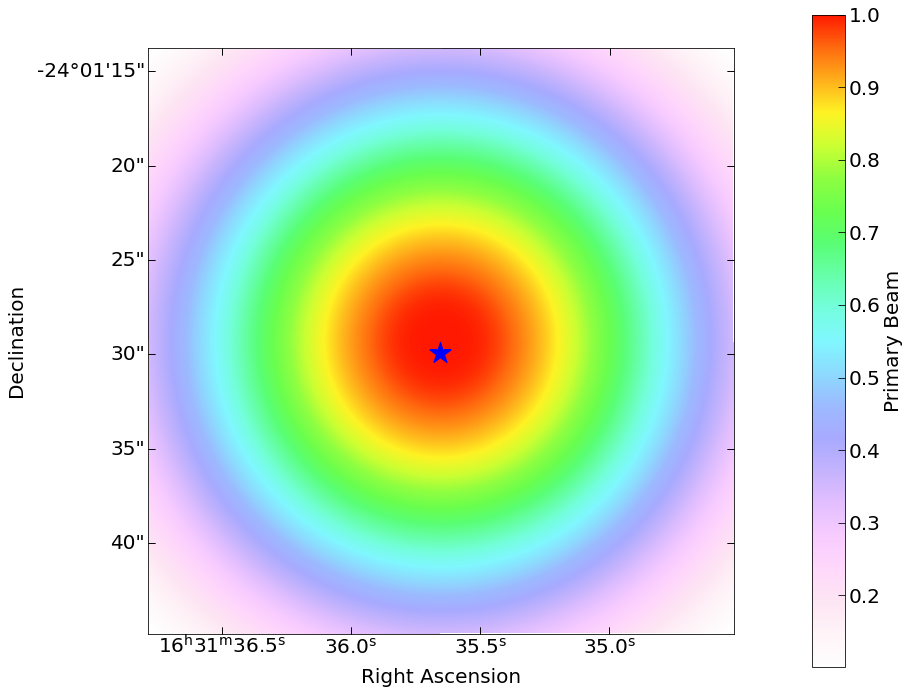

In [8]:
fig, ax = simple_plot(wcs, pb_map, 'Primary Beam', 
                           soft_colormap_v2, 
                           0, nx, 0, ny)


ax.scatter(x_cen, y_cen, marker = '*', s = 500, color = 'blue')

## Radius values and map

The paper says: We calculate the probability of detecting a galaxy at each threshold in annuli separated by $\sim 0.3''$

In [9]:
pixel_scale = np.abs(header["CDELT1"]) * 3600  # arcsec/pixel

radius_map = np.sqrt((x_grid - x_cen)**2 + (y_grid - y_cen)**2) * pixel_scale

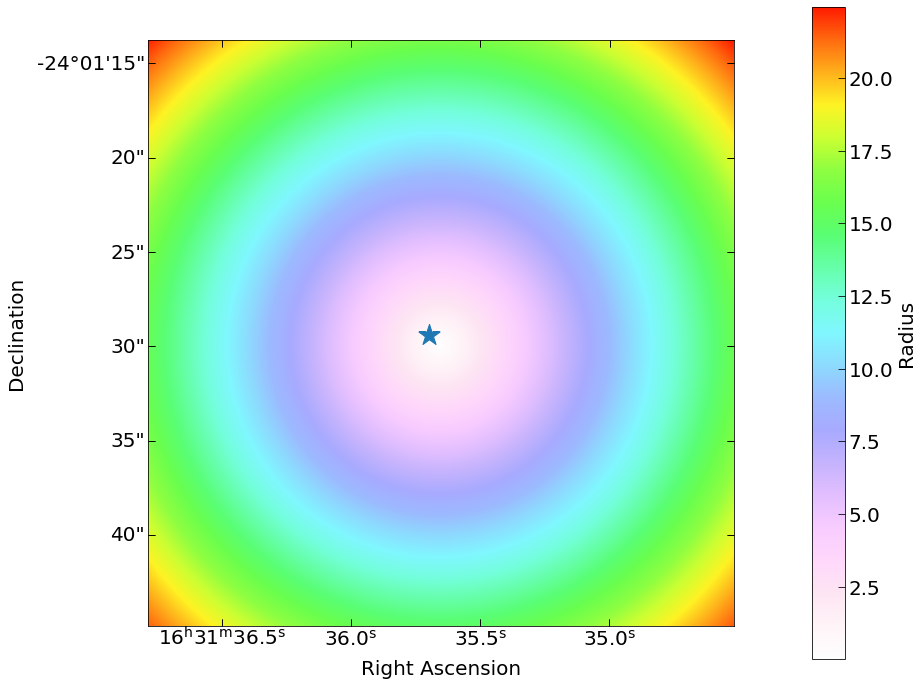

In [10]:
fig, ax = simple_plot(wcs, radius_map, 'Radius', 
                           soft_colormap_v2, 
                           0, nx, 0, ny)

ax.scatter(y_cen, x_cen, marker = '*', s = 500)

In [ ]:
pb_map[]

In [11]:
# every 14 pixels 
# annulus width is still 0.3 arcsec 


dr = 0.3        # arcsec 
max_radius = 22 # arcsec 

radius_array = np.arange(0, max_radius + dr, dr)

# radius_centers = (radius_array[:-1])

# radius_centers

## $\sigma(r)$

The paper says: $\sigma(r)$ is the map sensitivity as a function of position in the pimary beam. We adopt $\sigma=0.03$ mJy at the phase centre and allow $\sigma(r)$ to increase at larger radial extents accoring to the primary beam correction. 


More info:
divide the central sensitivity value (e.g., 0.03 mJy) by the primary beam value from the *.pb file.  So your noise goes up as you move away from the middle
 

## Galaxy Probability

The paper says: a Schechter function of the differential galaxy numbers of:

where $N$ is the number of galaxies with intensity $S$, and $S_0$ = 1.7 mJy. 

In [ ]:
# slice up for sigma(r)
# then do whole map 

# sample of DN for S, spline 

In [16]:
def galaxy_probability(sf, pb_profile):
    
    # divide central sensitivity value by primary beam value 
    sigma_r = 0.03 / pb_profile  
    
    # find S = sf * sigma(r)
    S = sf * sigma_r
    
    # S changes as a function of r 
    
    S_0 = 1.7 # this works for band 6
    
    dN_dS = 1800 * (S / S_0)**(-2.08) * np.exp(-S / S_0)
    
    return dN_dS



In [13]:
# sn_levels = [5, 10, 20]

# prob_band6 = []                # raw annuli probabilities per threshold
# prob_band6_norm = []           # normalized differential probabilities per annulus (%)
# prob_band6_cumulative = []     # cumulative probabilities per threshold


# # Loop over the 3 sn values 
# for sn in sn_levels:
    
#     prob_annuli = []
    
#     # Loop pver the annuli
#     for rmin, rmax in zip(radius_centers[:-1], radius_centers[1:]):
#         mask = (radius_map >= rmin) & (radius_map < rmax)
#         pb_annulus = pb_map[mask]
        
#         # In each annuli
#         p = galaxy_probability(sn, pb_annulus)
#         prob_annuli.append(np.nanmean(p)) 
    
#     prob_annuli = np.array(prob_annuli)
#     prob_band6.append(prob_annuli)
    
#     # normalized differential probability
#     prob_annuli_norm = 100 * prob_annuli / np.nansum(prob_annuli)
#     prob_band6_norm.append(prob_annuli_norm)
    
#     # cumulative detection probability
#     cumulative_prob = np.cumsum(prob_annuli_norm) * dr
#     prob_band6_cumulative.append(cumulative_prob)

In [25]:
dr_deg = 0.3 / 206265

In [29]:
sn_levels = [5]

prob_band6_norm = []           # normalized differential probabilities per annulus (%)
prob_band6_cumulative = []     # cumulative probabilities per threshold

radius_left = radius_array[:-1]
for sn in sn_levels:
    prob_annuli = []
    
    for rmin, rmax in zip(radius_left[:-1], radius_left[1:]):
        mask = (radius_map >= rmin) & (radius_map < rmax)
        pb_annulus = pb_map[mask]
        
        dN_dS_annulus = galaxy_probability(sn, pb_annulus)
        dN_dS_mean = np.nanmean(dN_dS_annulus)
        
        # Calculate annulus area in deg^2
        area_annulus = np.pi * (rmax**2 - rmin**2)
        area_annulus = 2 * np.pi * ((rmax + rmin)/2) * dr_deg
        
        # Expected number of galaxies in annulus
        N = dN_dS_mean * area_annulus
        
        prob_annuli.append(N)  # append to list here
    
    prob_annuli = np.array(prob_annuli)
    
    # Normalize differential probabilities as percentage of total counts
    prob_annuli_norm = 100 * prob_annuli / np.nansum(prob_annuli)
    prob_band6_norm.append(prob_annuli_norm)
    
    # Compute cumulative probability (%)
    cumulative_prob= np.cumsum(prob_annuli_norm)
    prob_band6_cumulative.append(cumulative_prob)


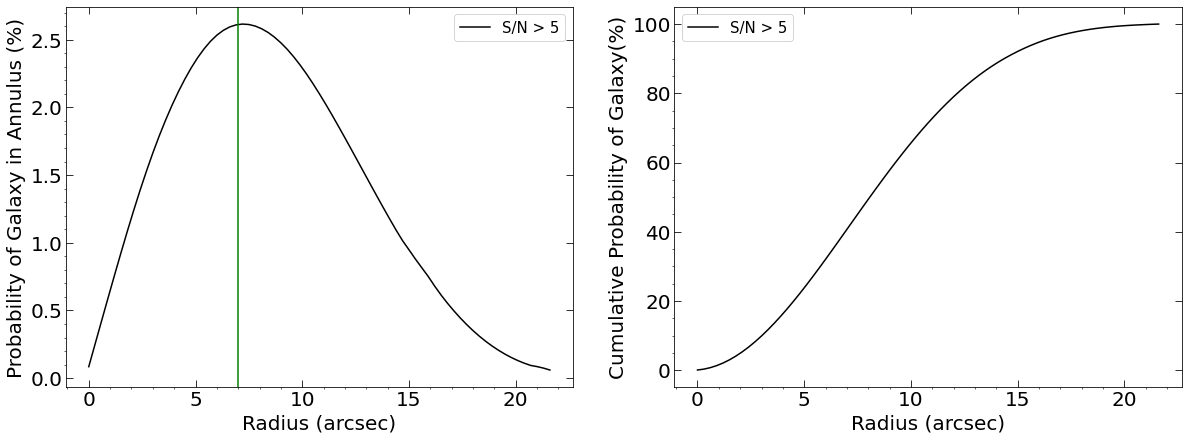

In [30]:
#
ls = ['-', '--', '-.']


fig, ax = plt.subplots(1, 2, figsize=(20, 7))


for i, N in enumerate(sn_levels):
    # Annular detection probability
    ax[0].plot(radius_left[:-1], prob_band6_norm[i], color='black', ls=ls[i], label=f'S/N > {N}')
    
    # Cumulative probability
    ax[1].plot(radius_left[:-1], prob_band6_cumulative[i], color='black', ls=ls[i], label=f'S/N > {N}')
    


ax[0].set_ylabel('Probability of Galaxy in Annulus (%)', fontsize = axis_label_fs)
ax[1].set_ylabel('Cumulative Probability of Galaxy(%)',  fontsize = axis_label_fs)


for i in range(2):
    
    # Add axis labels
    ax[i].set_xlabel(r'Radius (arcsec)', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
    
    ax[i].legend(fontsize = legend_text_fs)

# ax[0].axvline(9.3, color = 'blue')
# ax[0].axvline(8.8, color = 'red')
ax[0].axvline(7, color = 'green')

- 5 arcsec at band 5 and 7 at galaxy brightness
- do 1 - (not probability) = probability 